In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("Raw_Dataset.csv")
df.head(10)

,Student_ID,Student_Name,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Gender,Age,Study_Efficiency,Sleep_Hours,Internet_Usage_Hours
0,STU001,Krishna Iyer,NaN,74.9,41.4,83.800000,B,Male,-18,0.67,8.2,6.5
1,STU002,Ayushi Bansal,9.6,73.3,41.9,719.053401,D,female,20,0.74,NaN,5.8
2,STU003,Vivaan Gupta,7.6,67.0,40.1,60.800000,C,M,190.0898625,0.77,7.0,4.1
3,STU004,Manav Mehta,6.4,84.3,NaN,79.800000,NaN,Male,-23,0.85,7.0,NaN
4,STU005,Nikhil Nair,2.4,NaN,33.4,744.296559,C,M,23,NaN,8.2,2.7
5,STU006,Vihaan Agarwal,2.4,94.6,39.6,84.300000,B,Male,19,0.69,8.3,NaN
6,STU007,Aarav Kapoor,1.5,61.3,NaN,97.700000,A,Male,23,0.52,8.7,NaN
7,STU008,Harsh Singh,NaN,85.8,40.3,47.000000,D,Male,24,0.86,4.2,NaN
8,STU009,Tanvi Gupta,6.4,90.5,46.6,82.600000,NaN,F,NaN,NaN,8.5,1.1
9,STU010,Aadhya Chopra,7.4,90.4,40.0,53.800000,D,F,20,0.62,4.8,6.3


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 10000 non-null  object 
 1   Student_Name               10000 non-null  object 
 2   Study_Hours                8481 non-null   float64
 3   Attendance_Percentage      8452 non-null   float64
 4   Internal_Assessment_Score  8451 non-null   float64
 5   Previous_Academic_Result   8442 non-null   float64
 6   Final_Grade                8548 non-null   object 
 7   Gender                     8445 non-null   object 
 8   Age                        8792 non-null   object 
 9   Study_Efficiency           8614 non-null   float64
 10  Sleep_Hours                8641 non-null   float64
 11  Internet_Usage_Hours       8683 non-null   float64
dtypes: float64(7), object(5)
memory usage: 937.6+ KB


In [71]:
df.describe()

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Study_Efficiency,Sleep_Hours,Internet_Usage_Hours
count,8481.000000,8452.000000,8451.000000,8442.000000,8614.000000,8641.000000,8683.000000
mean,6.741150,99.470325,49.457934,86.875666,0.929432,8.666557,5.563720
std,8.773963,124.547023,62.098205,109.683405,1.159234,10.844334,7.146569
min,1.000000,60.000000,21.200000,40.000000,0.500000,4.000000,1.000000
25%,3.200000,70.500000,34.800000,55.700000,0.630000,5.600000,2.800000
50%,5.500000,80.700000,40.000000,70.900000,0.760000,7.100000,4.600000
75%,7.800000,90.900000,45.600000,85.800000,0.890000,8.600000,6.400000
max,67.340041,993.638245,494.039714,867.831462,9.284640,86.571171,55.579061


In [72]:
df.isnull().sum()

Student_ID                      0
Student_Name                    0
Study_Hours                  1519
Attendance_Percentage        1548
Internal_Assessment_Score    1549
Previous_Academic_Result     1558
Final_Grade                  1452
Gender                       1555
Age                          1208
Study_Efficiency             1386
Sleep_Hours                  1359
Internet_Usage_Hours         1317
dtype: int64

In [73]:

df['Sleep_Hours'].fillna(round(df['Sleep_Hours'].mean(),1),inplace=True)


df['Study_Hours'].fillna(round(df['Study_Hours'].mean(),1),inplace=True)


df['Attendance_Percentage'].fillna(round(df['Attendance_Percentage'].median(),1),inplace=True)


df['Internal_Assessment_Score'].fillna(round(df['Internal_Assessment_Score'].mean(),1),inplace=True)

df['Internet_Usage_Hours'].fillna(round(df['Internet_Usage_Hours'].mean(),1),inplace=True)

df['Study_Efficiency'].fillna(round(df['Study_Efficiency'].mean(),2),inplace=True)

df['Previous_Academic_Result'].fillna(round(df['Previous_Academic_Result'].mean(),1),inplace=True)



df['Gender'] = df['Gender'].str.strip().str.lower()
df['Gender'] = df['Gender'].replace(
    {'m': 'Male','male': 'Male','f': 'Female','female': 'Female'})
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)



df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df.loc[df['Age']<0,'Age']=np.nan
df.loc[(df['Age'] < 15) | (df['Age'] > 30), 'Age'] = np.nan
df['Age'].fillna(df['Age'].median(),inplace=True)


df.loc[df['Final_Grade'].isna(), 'Final_Grade'] = df['Previous_Academic_Result'].apply(
    lambda x: 'A' if x >=90 else
              'B' if x >= 75 else
              'C' if x >= 60 else
              'D' if x >= 40 else
              'F'
)

In [74]:
df = df.drop(['Student_ID', 'Student_Name'], axis=1)
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

In [75]:
df["Gender_Male"] = df["Gender_Male"].astype(int)

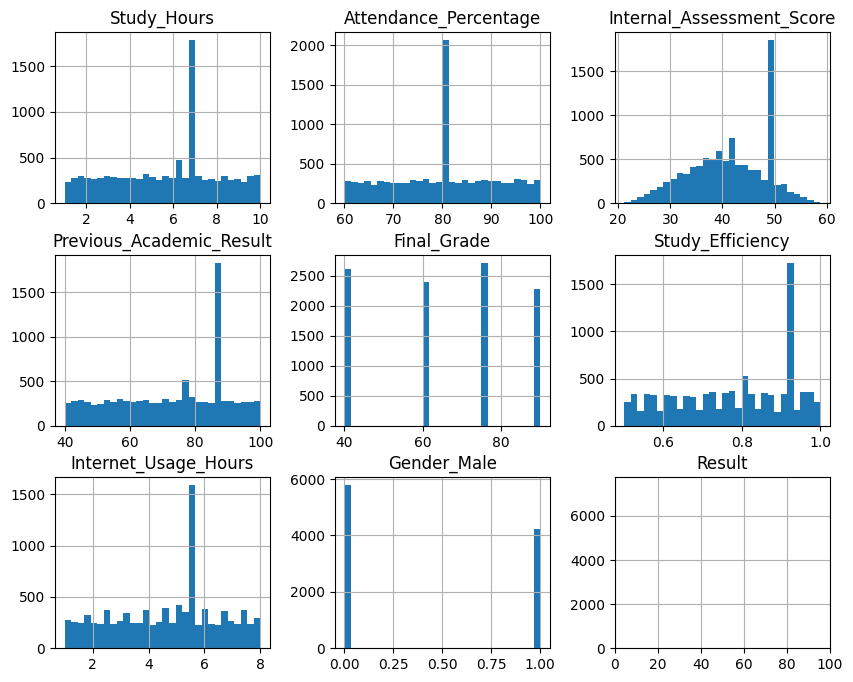

In [103]:
df.hist(figsize=(10,8), bins=30)
plt.xlim(0, 100)   
plt.show()

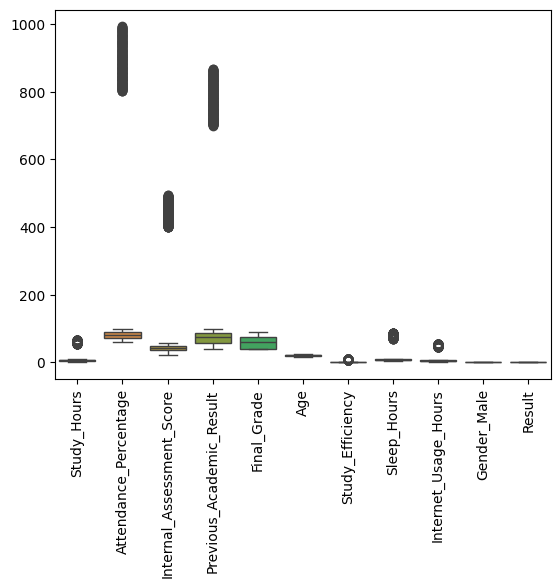

In [78]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

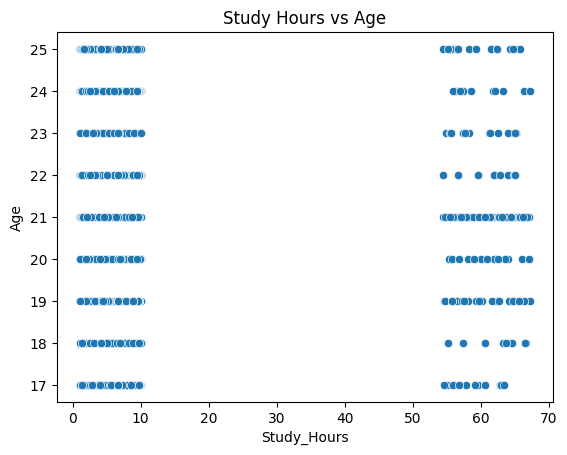

In [79]:
sns.scatterplot(x='Study_Hours', y='Age', data=df)
plt.title("Study Hours vs Age")
plt.show()

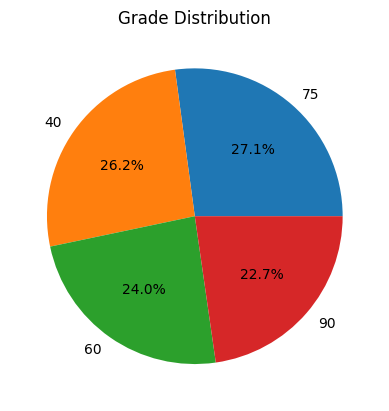

In [80]:
df['Final_Grade'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Grade Distribution")
plt.ylabel('')
plt.show()

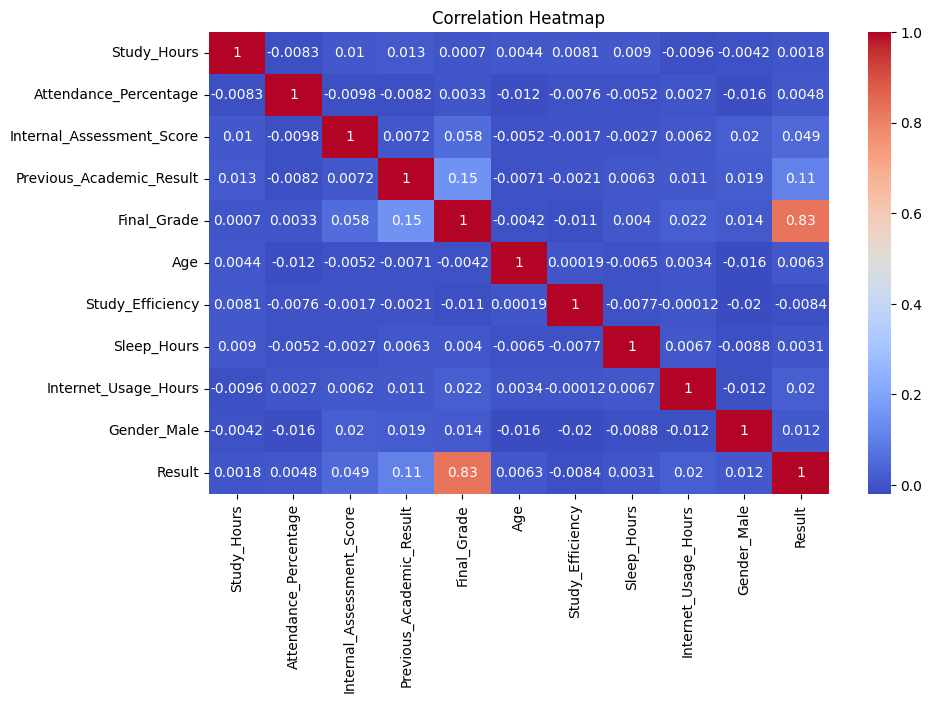

In [81]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [82]:
corr_target = df.corr()['Final_Grade'].abs().sort_values(ascending=False)
print("\nCorrelation with Final Grade:\n")
print(corr_target)


Correlation with Final Grade:

Final_Grade                  1.000000
Result                       0.830365
Previous_Academic_Result     0.151766
Internal_Assessment_Score    0.058252
Internet_Usage_Hours         0.021996
Gender_Male                  0.013837
Study_Efficiency             0.010588
Age                          0.004229
Sleep_Hours                  0.004023
Attendance_Percentage        0.003338
Study_Hours                  0.000704
Name: Final_Grade, dtype: float64


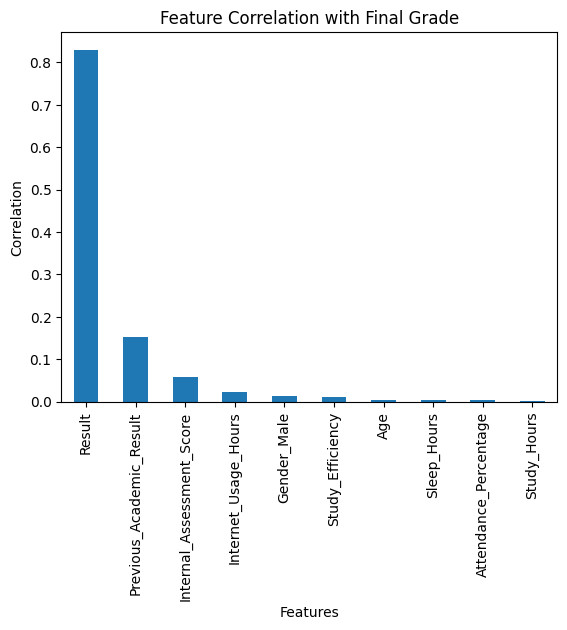

In [83]:
corr_target.drop('Final_Grade').plot(kind='bar', title='Feature Correlation with Final Grade')
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.show()

In [84]:
print(corr_target)

Final_Grade                  1.000000
Result                       0.830365
Previous_Academic_Result     0.151766
Internal_Assessment_Score    0.058252
Internet_Usage_Hours         0.021996
Gender_Male                  0.013837
Study_Efficiency             0.010588
Age                          0.004229
Sleep_Hours                  0.004023
Attendance_Percentage        0.003338
Study_Hours                  0.000704
Name: Final_Grade, dtype: float64


In [85]:
weak_features = corr_target[corr_target < 0.05].index
weak_features = weak_features.drop('Final_Grade', errors='ignore')

print("\nWeak Features (to drop):", list(weak_features))


Weak Features (to drop): ['Internet_Usage_Hours', 'Gender_Male', 'Study_Efficiency', 'Age', 'Sleep_Hours', 'Attendance_Percentage', 'Study_Hours']


In [86]:
print("Although some features show low correlation values, they are important from a domain perspective (e.g., Study Hours, Internal Assessment Score). Therefore, only less relevant features like Age, Sleep Hours were removed.")

Although some features show low correlation values, they are important from a domain perspective (e.g., Study Hours, Internal Assessment Score). Therefore, only less relevant features like Age, Sleep Hours were removed.


In [87]:
df.drop(columns=['Age', 'Sleep_Hours'], axis=1, inplace=True)
df

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.800000,75,0.67,6.5,1,1
1,9.6,73.3,41.9,719.053401,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.800000,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.800000,75,0.85,5.6,1,1
4,2.4,80.7,33.4,744.296559,60,0.93,2.7,1,1
...,...,...,...,...,...,...,...,...,...
9995,8.7,95.1,56.0,97.100000,90,0.78,3.3,1,1
9996,6.7,61.9,49.5,84.900000,75,0.54,4.4,0,1
9997,9.5,72.1,38.6,41.200000,40,0.65,1.8,1,0
9998,4.6,77.7,36.2,86.900000,60,0.93,5.5,1,1


In [88]:
df.head(21)

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.800000,75,0.67,6.5,1,1
1,9.6,73.3,41.9,719.053401,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.800000,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.800000,75,0.85,5.6,1,1
4,2.4,80.7,33.4,744.296559,60,0.93,2.7,1,1
5,2.4,94.6,39.6,84.300000,75,0.69,5.6,1,1
6,1.5,61.3,49.5,97.700000,90,0.52,5.6,1,1
7,6.7,85.8,40.3,47.000000,40,0.86,5.6,1,0
8,6.4,90.5,46.6,82.600000,75,0.93,1.1,0,1
9,7.4,90.4,40.0,53.800000,40,0.62,6.3,0,0


In [89]:
Q1 = df['Study_Hours'].quantile(0.25)
Q3 = df['Study_Hours'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


print("Study_Hours Outliers:\n", df[(df['Study_Hours'] < lower) | (df['Study_Hours'] > upper)])


df['Study_Hours'] = np.where(df['Study_Hours'] < lower, df['Study_Hours'].median(), df['Study_Hours'])
df['Study_Hours'] = np.where(df['Study_Hours'] > upper, df['Study_Hours'].median(), df['Study_Hours'])

print("Lower:", lower)
print("Upper:", upper)
print("Min:", df['Study_Hours'].min())
print("Max:", df['Study_Hours'].max())

Study_Hours Outliers:
       Study_Hours  Attendance_Percentage  Internal_Assessment_Score  \
67      58.294341                   90.1                       48.9   
90      61.517196                   80.7                       35.8   
156     56.928330                   69.2                       49.5   
375     57.855926                   79.7                       49.5   
409     66.251834                   66.2                       29.7   
...           ...                    ...                        ...   
9654    63.129755                   80.7                       49.5   
9819    56.803597                   92.2                       33.9   
9821    59.744346                   75.9                       47.4   
9923    60.584450                   89.3                       50.0   
9993    66.183693                   79.7                       39.0   

      Previous_Academic_Result  Final_Grade  Study_Efficiency  \
67                        78.4           75              0.

In [90]:
df

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.800000,75,0.67,6.5,1,1
1,9.6,73.3,41.9,719.053401,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.800000,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.800000,75,0.85,5.6,1,1
4,2.4,80.7,33.4,744.296559,60,0.93,2.7,1,1
...,...,...,...,...,...,...,...,...,...
9995,8.7,95.1,56.0,97.100000,90,0.78,3.3,1,1
9996,6.7,61.9,49.5,84.900000,75,0.54,4.4,0,1
9997,9.5,72.1,38.6,41.200000,40,0.65,1.8,1,0
9998,4.6,77.7,36.2,86.900000,60,0.93,5.5,1,1


In [91]:
Q1 = df['Attendance_Percentage'].quantile(0.25)
Q3 = df['Attendance_Percentage'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


outliers = df[(df['Attendance_Percentage'] < lower) | (df['Attendance_Percentage'] > upper)]
print("Outliers:\n", outliers)

df['Attendance_Percentage'] = np.where(df['Attendance_Percentage'] < lower, df['Attendance_Percentage'].median(), df['Attendance_Percentage'])
df['Attendance_Percentage'] = np.where(df['Attendance_Percentage'] > upper, df['Attendance_Percentage'].median(), df['Attendance_Percentage'])

print("Lower:", lower)
print("Upper:", upper)
print("Min:", df['Attendance_Percentage'].min())
print("Max:", df['Attendance_Percentage'].max())

Outliers:
       Study_Hours  Attendance_Percentage  Internal_Assessment_Score  \
26            2.8             988.309547                       29.9   
312           1.2             863.471574                       29.2   
406           4.5             923.161848                       49.5   
436           1.7             864.379057                       27.9   
534           7.9             854.314134                       43.8   
...           ...                    ...                        ...   
9783          9.4             962.935467                       46.0   
9801          2.8             953.561165                       32.9   
9834          6.7             821.967232                       30.3   
9871          5.7             820.192029                       32.1   
9982          3.8             806.273532                       44.4   

      Previous_Academic_Result  Final_Grade  Study_Efficiency  \
26                        48.9           40              0.69   
312   

In [92]:
df

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.800000,75,0.67,6.5,1,1
1,9.6,73.3,41.9,719.053401,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.800000,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.800000,75,0.85,5.6,1,1
4,2.4,80.7,33.4,744.296559,60,0.93,2.7,1,1
...,...,...,...,...,...,...,...,...,...
9995,8.7,95.1,56.0,97.100000,90,0.78,3.3,1,1
9996,6.7,61.9,49.5,84.900000,75,0.54,4.4,0,1
9997,9.5,72.1,38.6,41.200000,40,0.65,1.8,1,0
9998,4.6,77.7,36.2,86.900000,60,0.93,5.5,1,1


In [93]:
Q1 = df['Internal_Assessment_Score'].quantile(0.25)
Q3 = df['Internal_Assessment_Score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Internal Score Outliers:\n", df[(df['Internal_Assessment_Score'] < lower) | (df['Internal_Assessment_Score'] > upper)])

df['Internal_Assessment_Score'] = np.where(df['Internal_Assessment_Score'] < lower, df['Internal_Assessment_Score'].median(), df['Internal_Assessment_Score'])
df['Internal_Assessment_Score'] = np.where(df['Internal_Assessment_Score'] > upper, df['Internal_Assessment_Score'].median(), df['Internal_Assessment_Score'])
print("Lower:", lower)
print("Upper:", upper)
print("Min:", df['Internal_Assessment_Score'].min())
print("Max:", df['Internal_Assessment_Score'].max())

Internal Score Outliers:
       Study_Hours  Attendance_Percentage  Internal_Assessment_Score  \
59            3.9                   80.7                 412.718848   
153           5.4                   62.1                 407.860975   
249           8.7                   60.8                 439.625494   
253           3.9                   76.1                 423.021935   
307           3.9                   69.4                 469.013058   
...           ...                    ...                        ...   
9327          2.9                   81.8                 408.296466   
9537          8.0                   90.0                 437.738553   
9616          7.2                   84.2                 489.235326   
9712          3.3                   78.7                 442.967509   
9833         10.0                   98.9                 482.423885   

      Previous_Academic_Result  Final_Grade  Study_Efficiency  \
59                        80.1           75             

In [94]:
df

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.800000,75,0.67,6.5,1,1
1,9.6,73.3,41.9,719.053401,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.800000,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.800000,75,0.85,5.6,1,1
4,2.4,80.7,33.4,744.296559,60,0.93,2.7,1,1
...,...,...,...,...,...,...,...,...,...
9995,8.7,95.1,56.0,97.100000,90,0.78,3.3,1,1
9996,6.7,61.9,49.5,84.900000,75,0.54,4.4,0,1
9997,9.5,72.1,38.6,41.200000,40,0.65,1.8,1,0
9998,4.6,77.7,36.2,86.900000,60,0.93,5.5,1,1


In [95]:
Q1 = df['Internet_Usage_Hours'].quantile(0.25)
Q3 = df['Internet_Usage_Hours'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Internet_Usage_Hours Outliers:\n", df[(df['Internet_Usage_Hours'] < lower) | (df['Internet_Usage_Hours'] > upper)])

df['Internet_Usage_Hours'] = np.where(df['Internet_Usage_Hours'] < lower, df['Internet_Usage_Hours'].median(), df['Internet_Usage_Hours'])
df['Internet_Usage_Hours'] = np.where(df['Internet_Usage_Hours'] > upper, df['Internet_Usage_Hours'].median(), df['Internet_Usage_Hours'])
print("Lower:", lower)
print("Upper:", upper)
print("Min:", df['Internet_Usage_Hours'].min())
print("Max:", df['Internet_Usage_Hours'].max())

Internet_Usage_Hours Outliers:
       Study_Hours  Attendance_Percentage  Internal_Assessment_Score  \
293           4.2                   87.1                       49.5   
313           9.7                   62.1                       54.7   
435           7.3                   80.7                       45.0   
475           9.9                   77.4                       54.1   
511           4.8                   82.2                       41.6   
...           ...                    ...                        ...   
9631          7.3                   64.0                       44.7   
9699          6.7                   84.0                       48.2   
9710          2.7                   73.1                       38.0   
9791          5.7                   80.4                       36.9   
9980          4.2                   95.6                       34.0   

      Previous_Academic_Result  Final_Grade  Study_Efficiency  \
293                  94.700000           90       

In [96]:
df

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.800000,75,0.67,6.5,1,1
1,9.6,73.3,41.9,719.053401,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.800000,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.800000,75,0.85,5.6,1,1
4,2.4,80.7,33.4,744.296559,60,0.93,2.7,1,1
...,...,...,...,...,...,...,...,...,...
9995,8.7,95.1,56.0,97.100000,90,0.78,3.3,1,1
9996,6.7,61.9,49.5,84.900000,75,0.54,4.4,0,1
9997,9.5,72.1,38.6,41.200000,40,0.65,1.8,1,0
9998,4.6,77.7,36.2,86.900000,60,0.93,5.5,1,1


In [97]:
Q1 = df['Previous_Academic_Result'].quantile(0.25)
Q3 = df['Previous_Academic_Result'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Previous_Academic_Result Outliers:\n", df[(df['Previous_Academic_Result'] < lower) | (df['Previous_Academic_Result'] > upper)])

df['Previous_Academic_Result'] = np.where(df['Previous_Academic_Result'] < lower, df['Previous_Academic_Result'].median(), df['Previous_Academic_Result'])
df['Previous_Academic_Result'] = np.where(df['Previous_Academic_Result'] > upper, df['Previous_Academic_Result'].median(), df['Previous_Academic_Result'])
print("Lower:", lower)
print("Upper:", upper)
print("Min:", df['Previous_Academic_Result'].min())
print("Max:", df['Previous_Academic_Result'].max())

Previous_Academic_Result Outliers:
       Study_Hours  Attendance_Percentage  Internal_Assessment_Score  \
1             9.6                   73.3                       41.9   
4             2.4                   80.7                       33.4   
144           6.7                   85.0                       39.4   
195           6.7                   80.7                       49.5   
259           6.7                   63.4                       31.3   
...           ...                    ...                        ...   
9784          5.9                   82.1                       32.9   
9808          9.9                   84.3                       57.3   
9883          9.4                   66.9                       55.2   
9898          8.5                   96.7                       49.5   
9951          6.7                   98.1                       41.8   

      Previous_Academic_Result  Final_Grade  Study_Efficiency  \
1                   719.053401           40   

In [98]:
df

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.8,75,0.67,6.5,1,1
1,9.6,73.3,41.9,76.4,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.8,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.8,75,0.85,5.6,1,1
4,2.4,80.7,33.4,76.4,60,0.93,2.7,1,1
...,...,...,...,...,...,...,...,...,...
9995,8.7,95.1,56.0,97.1,90,0.78,3.3,1,1
9996,6.7,61.9,49.5,84.9,75,0.54,4.4,0,1
9997,9.5,72.1,38.6,41.2,40,0.65,1.8,1,0
9998,4.6,77.7,36.2,86.9,60,0.93,5.5,1,1


In [99]:

Q1 = df['Study_Efficiency'].quantile(0.25)
Q3 = df['Study_Efficiency'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Study_Efficiency Outliers:\n", df[(df['Study_Efficiency'] < lower) | (df['Study_Efficiency'] > upper)])

df['Study_Efficiency'] = np.where(df['Study_Efficiency'] < lower, df['Study_Efficiency'].median(), df['Study_Efficiency'])
df['Study_Efficiency'] = np.where(df['Study_Efficiency'] > upper, df['Study_Efficiency'].median(), df['Study_Efficiency'])

print("Lower:", lower)
print("Upper:", upper)
print("Min:", df['Study_Efficiency'].min())
print("Max:", df['Study_Efficiency'].max())

Study_Efficiency Outliers:
       Study_Hours  Attendance_Percentage  Internal_Assessment_Score  \
92            7.8                   80.7                       49.5   
193           6.7                   95.5                       46.9   
288           3.6                   84.8                       49.5   
294           2.1                   80.7                       30.0   
510           6.5                   64.9                       34.7   
...           ...                    ...                        ...   
9666          1.4                   79.1                       32.1   
9682          3.8                   84.7                       38.2   
9758          2.8                   86.0                       31.0   
9810          2.0                   67.8                       30.3   
9981          6.4                   80.7                       39.7   

      Previous_Academic_Result  Final_Grade  Study_Efficiency  \
92                        83.7           75          8

In [100]:
df

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.8,75,0.67,6.5,1,1
1,9.6,73.3,41.9,76.4,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.8,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.8,75,0.85,5.6,1,1
4,2.4,80.7,33.4,76.4,60,0.93,2.7,1,1
...,...,...,...,...,...,...,...,...,...
9995,8.7,95.1,56.0,97.1,90,0.78,3.3,1,1
9996,6.7,61.9,49.5,84.9,75,0.54,4.4,0,1
9997,9.5,72.1,38.6,41.2,40,0.65,1.8,1,0
9998,4.6,77.7,36.2,86.9,60,0.93,5.5,1,1


In [101]:
df.to_csv("Cleaned_Dataset.csv", index=False)